# Advanced Attendance Prediction Models - PortAventura World

This notebook compares **4 advanced models** against the baseline SARIMAX for predicting PortAventura World daily attendance.

**Models:**
1. **Prophet** (Meta) - Handles seasonality + COVID changepoints natively
2. **XGBoost** - Gradient boosting with engineered temporal + weather features
3. **STL+ETS** - Seasonal decomposition + Exponential Smoothing
4. **Bayesian Structural Time Series** - Unobserved Components with COVID intervention

**Key improvements over SARIMAX baseline (R²=-4.52, MAPE=58%):**
- Daily data (~1,200 rows) instead of monthly (~50 rows)
- Weather features as exogenous regressors
- Proper COVID structural break handling

In [1]:
# ============================================================
# SETUP & IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Model imports
from prophet import Prophet
import xgboost as xgb
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('All libraries imported successfully')

Importing plotly failed. Interactive plots will not work.


All libraries imported successfully


## 1. Data Pipeline — Load, Clean, Feature-Engineer

In [2]:
# ============================================================
# 1a. LOAD ATTENDANCE DATA
# ============================================================
att = pd.read_csv('../final_data/attendance.csv')
att['USAGE_DATE'] = pd.to_datetime(att['USAGE_DATE'])

# Filter to PortAventura World only
pa = att[att['FACILITY_NAME'] == 'PortAventura World'].copy()
pa = pa.rename(columns={'USAGE_DATE': 'date', 'attendance': 'y'})
pa = pa[['date', 'y']].sort_values('date').reset_index(drop=True)

print(f"PortAventura daily attendance: {len(pa)} rows")
print(f"Date range: {pa['date'].min().date()} → {pa['date'].max().date()}")
print(f"\nAttendance stats:")
print(pa['y'].describe())

# Flag and clean anomalous values (negatives, near-zero during non-COVID)
print(f"\nNegative values: {(pa['y'] < 0).sum()}")
print(f"Values < 100: {(pa['y'] < 100).sum()}")
pa.head()

PortAventura daily attendance: 1182 rows
Date range: 2018-06-01 → 2022-07-26

Attendance stats:
count     1182.000000
mean     34796.605753
std      18325.289439
min      -9991.000000
25%      21701.000000
50%      35672.500000
75%      49563.500000
max      80642.000000
Name: y, dtype: float64

Negative values: 37
Values < 100: 38


,date,y
0,2018-06-01,46804
1,2018-06-02,57940
2,2018-06-03,44365
3,2018-06-04,37617
4,2018-06-05,32438


In [3]:
# ============================================================
# 1b. LOAD & AGGREGATE WEATHER DATA (hourly → daily)
# ============================================================
weather = pd.read_csv('../final_data/weather_data.csv')
weather['date'] = pd.to_datetime(weather['dt_iso'].str[:19])
weather['date_only'] = weather['date'].dt.date

# Aggregate to daily
weather_daily = weather.groupby('date_only').agg(
    temp_mean=('temp', 'mean'),
    temp_min=('temp', 'min'),
    temp_max=('temp', 'max'),
    feels_like_mean=('feels_like', 'mean'),
    humidity_mean=('humidity', 'mean'),
    wind_speed_mean=('wind_speed', 'mean'),
    wind_speed_max=('wind_speed', 'max'),
    pressure_mean=('pressure', 'mean'),
    clouds_mean=('clouds_all', 'mean'),
    rain_total=('rain_1h', lambda x: x.fillna(0).sum()),
    snow_total=('snow_1h', lambda x: x.fillna(0).sum()),
).reset_index()
weather_daily['date_only'] = pd.to_datetime(weather_daily['date_only'])
weather_daily = weather_daily.rename(columns={'date_only': 'date'})

print(f"Weather daily: {len(weather_daily)} rows")
print(f"Date range: {weather_daily['date'].min().date()} → {weather_daily['date'].max().date()}")
weather_daily.head()

Weather daily: 8636 rows
Date range: 1999-01-01 → 2022-08-23


,date,temp_mean,temp_min,temp_max,feels_like_mean,humidity_mean,wind_speed_mean,wind_speed_max,pressure_mean,clouds_mean,rain_total,snow_total
0,1999-01-01,7.954167,5.45,12.09,5.552500,82.541667,4.182500,5.57,1009.166667,52.291667,0.00,0.0
1,1999-01-02,7.442500,5.26,9.72,3.710833,87.916667,6.901250,8.66,1006.458333,86.375000,3.43,0.0
2,1999-01-03,7.706250,4.74,12.02,4.600833,82.708333,6.913750,10.85,1009.208333,83.833333,6.07,0.0
3,1999-01-04,12.067500,7.53,13.98,11.342083,93.583333,6.536667,7.62,1015.291667,97.791667,5.00,0.0
4,1999-01-05,11.275833,7.66,15.91,10.225833,88.083333,3.827917,4.53,1017.958333,52.458333,0.00,0.0


In [4]:
# ============================================================
# 1c. MERGE & FEATURE ENGINEERING
# ============================================================
df = pa.merge(weather_daily, on='date', how='left')
print(f"Merged dataset: {len(df)} rows, {df.shape[1]} columns")
print(f"Missing weather rows: {df['temp_mean'].isna().sum()}")

# --- Calendar features ---
df['day_of_week'] = df['date'].dt.dayofweek        # 0=Mon, 6=Sun
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['year'] = df['date'].dt.year

# Summer / holiday season flags
df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
df['is_holiday_season'] = df['month'].isin([6, 7, 8, 12]).astype(int)

# --- COVID features ---
covid_start = pd.Timestamp('2020-02-01')
covid_end   = pd.Timestamp('2021-06-30')
df['is_covid'] = ((df['date'] >= covid_start) & (df['date'] <= covid_end)).astype(int)
df['is_recovery'] = (df['date'] > covid_end).astype(int)

# Recovery ramp: months since COVID ended (gradual return)
df['recovery_months'] = np.where(
    df['date'] > covid_end,
    ((df['date'] - covid_end).dt.days / 30.44).clip(upper=12),
    0.0
)

# --- Clean negative attendance ---
# Replace negative values with NaN then interpolate
neg_mask = df['y'] < 0
print(f"Replacing {neg_mask.sum()} negative attendance values via interpolation")
df.loc[neg_mask, 'y'] = np.nan
df['y'] = df['y'].interpolate(method='linear')

# --- Forward-fill any missing weather ---
weather_cols = ['temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
                'humidity_mean', 'wind_speed_mean', 'wind_speed_max',
                'pressure_mean', 'clouds_mean', 'rain_total', 'snow_total']
df[weather_cols] = df[weather_cols].ffill().bfill()

# --- Has rain / has snow binary ---
df['has_rain'] = (df['rain_total'] > 0).astype(int)
df['has_snow'] = (df['snow_total'] > 0).astype(int)

print(f"\nFinal dataset: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Any NaN in target: {df['y'].isna().sum()}")
df.head()

Merged dataset: 1182 rows, 13 columns
Missing weather rows: 0
Replacing 37 negative attendance values via interpolation

Final dataset: (1182, 26)
Date range: 2018-06-01 → 2022-07-26
Any NaN in target: 0


,date,y,temp_mean,temp_min,temp_max,feels_like_mean,humidity_mean,wind_speed_mean,wind_speed_max,pressure_mean,...,day_of_year,is_weekend,year,is_summer,is_holiday_season,is_covid,is_recovery,recovery_months,has_rain,has_snow
0,2018-06-01,46804.0,17.887500,15.79,20.50,18.080417,89.916667,2.472917,4.02,1019.333333,...,152,0,2018,1,1,0,0,0.0,1,0
1,2018-06-02,57940.0,19.352500,15.27,23.71,19.368333,77.541667,1.468750,2.47,1019.458333,...,153,1,2018,1,1,0,0,0.0,0,0
2,2018-06-03,44365.0,20.275833,14.13,25.11,20.255833,72.666667,2.939167,3.75,1016.375000,...,154,1,2018,1,1,0,0,0.0,0,0
3,2018-06-04,37617.0,20.721667,16.96,24.93,20.802500,74.791667,2.471250,3.40,1011.166667,...,155,0,2018,1,1,0,0,0.0,1,0
4,2018-06-05,32438.0,18.089583,15.77,21.67,18.168750,84.791667,3.377917,4.72,1011.000000,...,156,0,2018,1,1,0,0,0.0,1,0


Train: 1092 days  (2018-06-01 → 2022-04-27)
Test:  90 days  (2022-04-28 → 2022-07-26)


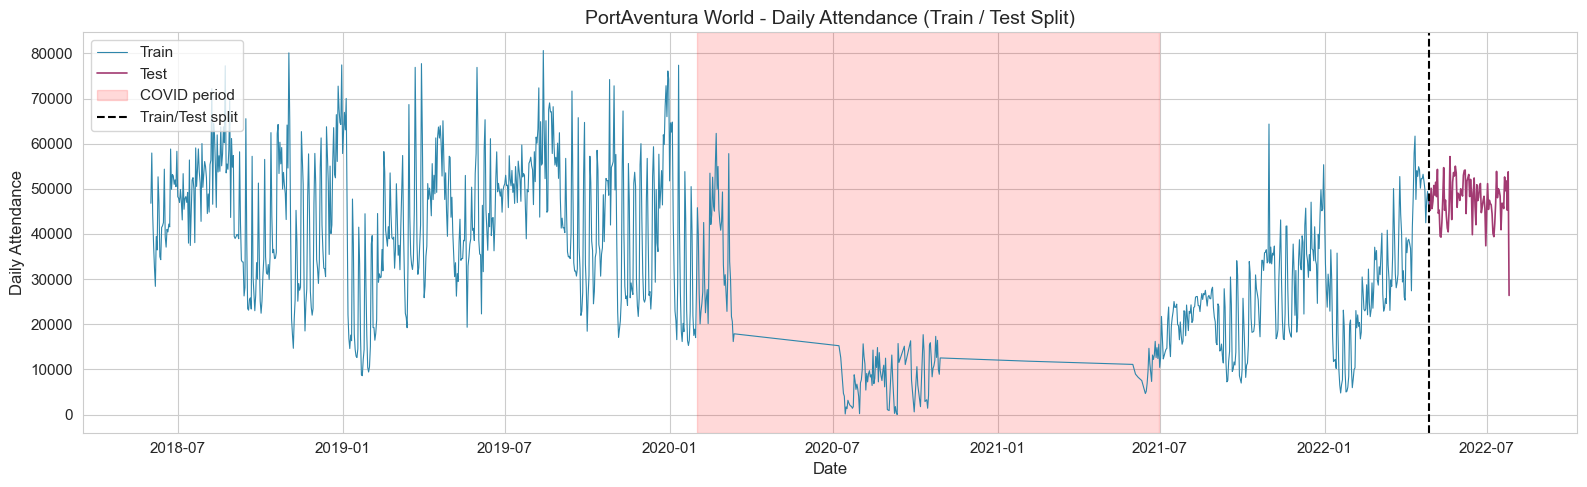

In [5]:
# ============================================================
# 1d. TRAIN / TEST SPLIT  (last 90 days ≈ 3 months)
# ============================================================
TEST_DAYS = 90

df = df.sort_values('date').reset_index(drop=True)
split_idx = len(df) - TEST_DAYS

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} days  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Test:  {len(test_df)} days  ({test_df['date'].min().date()} → {test_df['date'].max().date()})")

# Visualize the split
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_df['date'], train_df['y'], color='#2E86AB', label='Train', linewidth=0.8)
ax.plot(test_df['date'], test_df['y'], color='#A23B72', label='Test', linewidth=1.2)
ax.axvspan(covid_start, covid_end, alpha=0.15, color='red', label='COVID period')
ax.axvline(test_df['date'].iloc[0], color='black', linestyle='--', label='Train/Test split')
ax.set_title('PortAventura World - Daily Attendance (Train / Test Split)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Attendance')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# HELPER: Evaluation metrics (shared by all models)
# ============================================================
def evaluate(y_true, y_pred, model_name='Model'):
    """Compute and return a dict of evaluation metrics."""
    mask = y_true > 0  # avoid div-by-zero for MAPE
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  MAE  : {mae:>12,.0f}")
    print(f"  RMSE : {rmse:>12,.0f}")
    print(f"  R²   : {r2:>12.4f}")
    print(f"  MAPE : {mape:>11.2f}%")
    print(f"{'='*55}")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Store all results here
results = {}
predictions = {}

## 2. Model 1 — Facebook Prophet

Prophet handles:
- **Yearly + weekly seasonality** out of the box
- **COVID as a custom holiday window** — the model suppresses predictions for that period
- **Weather regressors** (temp, rain, humidity) as additional regressors
- **Changepoints** to adapt to structural shifts in trend

In [7]:
# ============================================================
# MODEL 1: PROPHET
# ============================================================

# Prepare Prophet dataframe (requires columns 'ds' and 'y')
prophet_train = train_df[['date', 'y']].rename(columns={'date': 'ds'}).copy()
prophet_test  = test_df[['date', 'y']].rename(columns={'date': 'ds'}).copy()

# Add weather regressors
regressor_cols = ['temp_mean', 'humidity_mean', 'rain_total', 'wind_speed_mean', 'is_covid']
for col in regressor_cols:
    prophet_train[col] = train_df[col].values
    prophet_test[col]  = test_df[col].values

# Define COVID lockdown as a custom holiday window
covid_dates = pd.date_range(start=covid_start, end=covid_end, freq='D')
covid_holidays = pd.DataFrame({
    'holiday': 'covid_lockdown',
    'ds': covid_dates,
    'lower_window': 0,
    'upper_window': 0,
})

# Build Prophet model
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=covid_holidays,
    changepoint_prior_scale=0.1,   # moderate flexibility
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0,
    changepoint_range=0.9,
)

# Add weather regressors
for col in regressor_cols:
    model_prophet.add_regressor(col)

# Fit
model_prophet.fit(prophet_train)

# Predict on train + test
prophet_future = pd.concat([prophet_train, prophet_test], ignore_index=True)
prophet_forecast = model_prophet.predict(prophet_future)

# Extract test predictions
prophet_pred_test = prophet_forecast.iloc[-len(test_df):]['yhat'].values
prophet_pred_test = np.clip(prophet_pred_test, 0, None)  # attendance can't be negative

# Evaluate
results['Prophet'] = evaluate(test_df['y'].values, prophet_pred_test, 'Prophet')
predictions['Prophet'] = prophet_pred_test

print("\nProphet model fitted successfully")

16:33:38 - cmdstanpy - INFO - Chain [1] start processing


16:33:39 - cmdstanpy - INFO - Chain [1] done processing



  Prophet
  MAE  :       11,674
  RMSE :       13,254
  R²   :      -6.7598
  MAPE :       24.42%

Prophet model fitted successfully


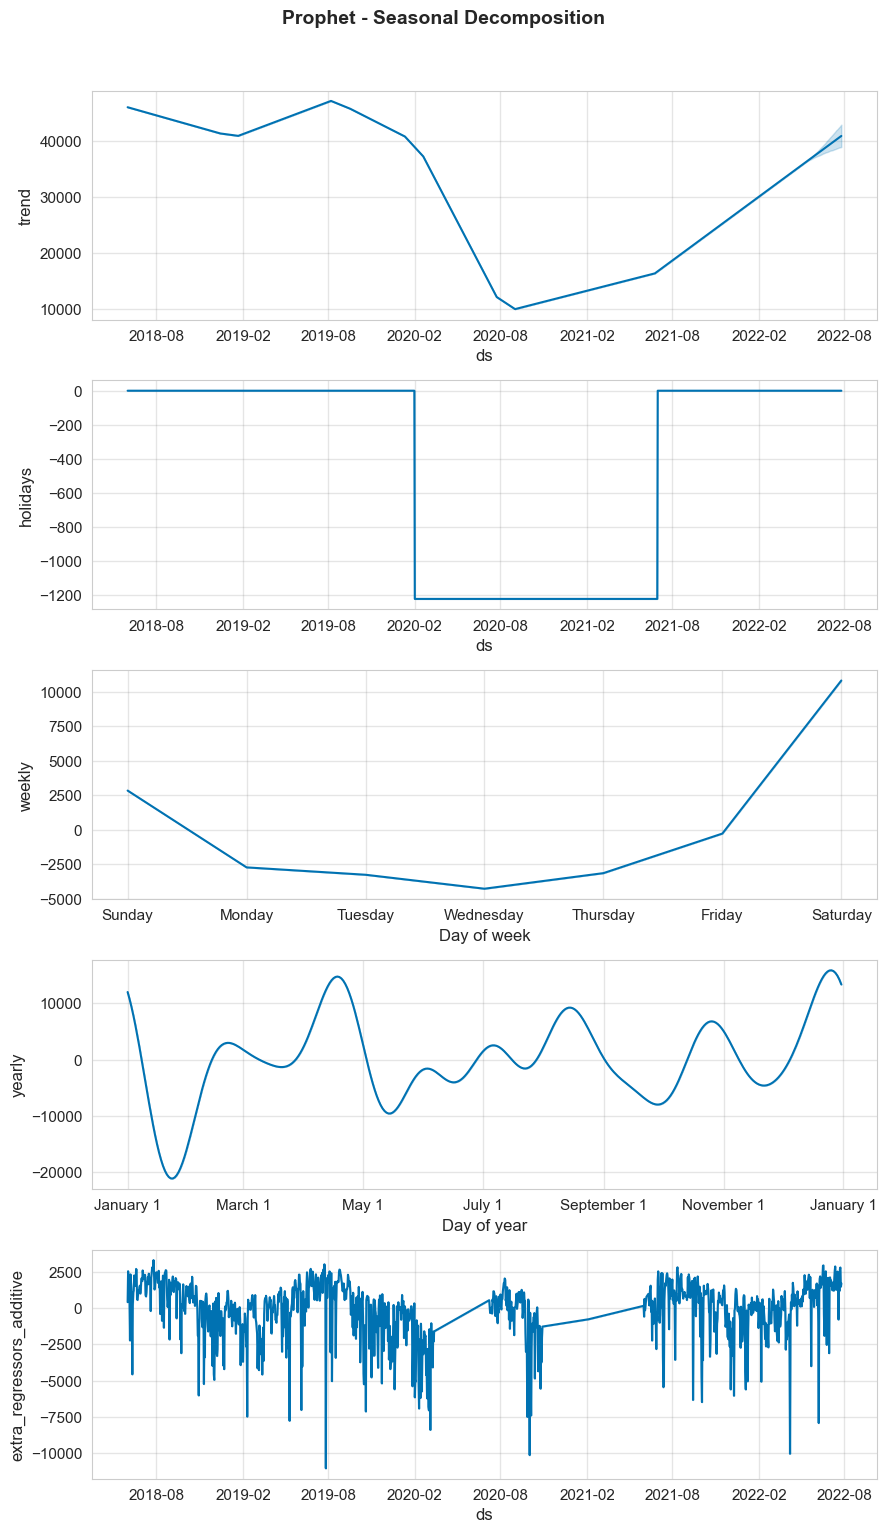

In [8]:
# Prophet decomposition plot
fig = model_prophet.plot_components(prophet_forecast)
fig.suptitle('Prophet - Seasonal Decomposition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Model 2 — XGBoost with Feature Engineering

Gradient boosting on tabular features:
- **Calendar**: day_of_week, month, week_of_year, is_weekend, is_summer, is_holiday_season
- **Lag features**: attendance 7, 14, 28, 365 days ago + rolling means
- **Weather**: temperature, rain, humidity, wind, clouds
- **COVID**: binary flag + recovery ramp

In [9]:
# ============================================================
# MODEL 2: XGBOOST with feature engineering
# ============================================================

# Build lag & rolling features on the FULL dataframe, then split
df_xgb = df.copy()
df_xgb = df_xgb.set_index('date').sort_index()

# Lag features (careful: only use past data)
for lag in [7, 14, 28, 365]:
    df_xgb[f'lag_{lag}'] = df_xgb['y'].shift(lag)

# Rolling statistics
for window in [7, 14, 30]:
    df_xgb[f'roll_mean_{window}'] = df_xgb['y'].shift(1).rolling(window).mean()
    df_xgb[f'roll_std_{window}']  = df_xgb['y'].shift(1).rolling(window).std()

# Cyclical encoding of day_of_week and month (better for tree models too)
df_xgb['dow_sin'] = np.sin(2 * np.pi * df_xgb['day_of_week'] / 7)
df_xgb['dow_cos'] = np.cos(2 * np.pi * df_xgb['day_of_week'] / 7)
df_xgb['month_sin'] = np.sin(2 * np.pi * df_xgb['month'] / 12)
df_xgb['month_cos'] = np.cos(2 * np.pi * df_xgb['month'] / 12)

# Drop rows with NaN from lagging (mostly the first 365 days)
df_xgb = df_xgb.dropna()

# Feature columns
feature_cols = [
    # Calendar
    'day_of_week', 'month', 'week_of_year', 'day_of_year', 'is_weekend', 'year',
    'is_summer', 'is_holiday_season',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Weather
    'temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
    'humidity_mean', 'wind_speed_mean', 'pressure_mean', 'clouds_mean',
    'rain_total', 'has_rain',
    # COVID
    'is_covid', 'is_recovery', 'recovery_months',
    # Lags & rolling
    'lag_7', 'lag_14', 'lag_28', 'lag_365',
    'roll_mean_7', 'roll_mean_14', 'roll_mean_30',
    'roll_std_7', 'roll_std_14', 'roll_std_30',
]

# Split based on date (same cutoff as main split)
split_date = test_df['date'].iloc[0]
xgb_train = df_xgb[df_xgb.index < split_date]
xgb_test  = df_xgb[df_xgb.index >= split_date]

X_train = xgb_train[feature_cols]
y_train_xgb = xgb_train['y']
X_test  = xgb_test[feature_cols]
y_test_xgb  = xgb_test['y']

print(f"XGBoost train: {len(X_train)} rows, {X_train.shape[1]} features")
print(f"XGBoost test:  {len(X_test)} rows")

# Train XGBoost
model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=30,
)

model_xgb.fit(
    X_train, y_train_xgb,
    eval_set=[(X_test, y_test_xgb)],
    verbose=False,
)

xgb_pred_test = model_xgb.predict(X_test)
xgb_pred_test = np.clip(xgb_pred_test, 0, None)

# Align with test_df dates
# (xgb_test might have slightly fewer rows if lag_365 excluded early dates)
xgb_test_dates = xgb_test.index
results['XGBoost'] = evaluate(y_test_xgb.values, xgb_pred_test, 'XGBoost')
predictions['XGBoost'] = (xgb_test_dates, xgb_pred_test, y_test_xgb.values)

XGBoost train: 727 rows, 35 features
XGBoost test:  90 rows



  XGBoost
  MAE  :        3,425
  RMSE :        4,785
  R²   :      -0.0113
  MAPE :        7.71%


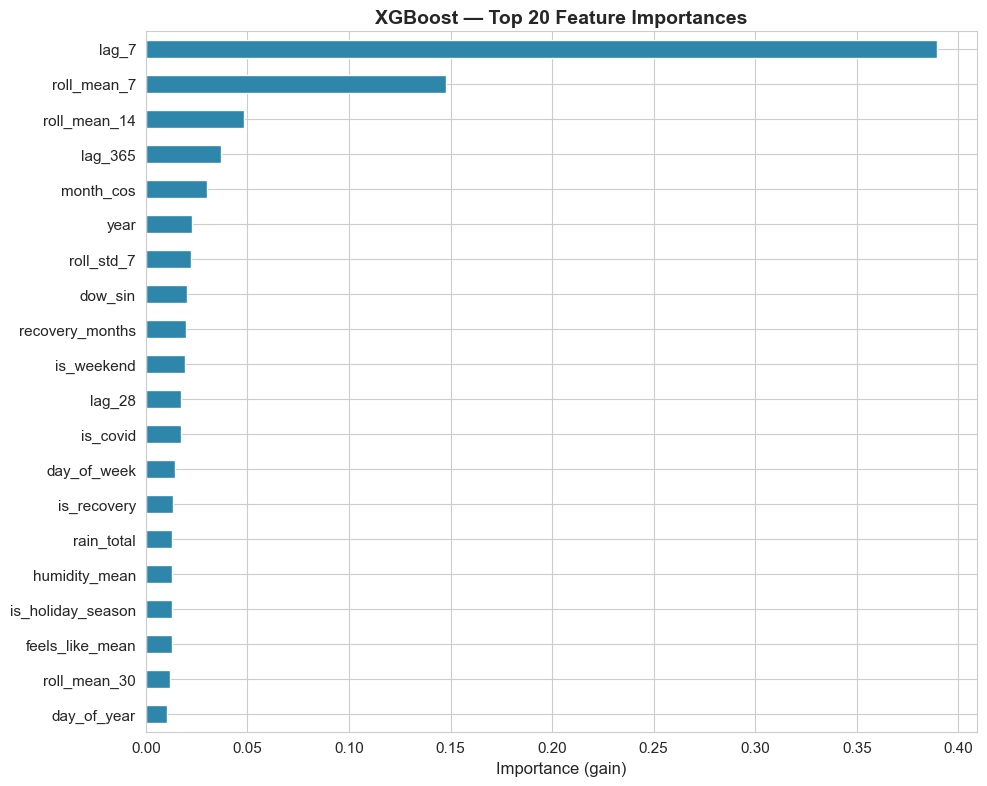

In [10]:
# XGBoost Feature Importance (top 20)
fig, ax = plt.subplots(figsize=(10, 8))
importances = pd.Series(model_xgb.feature_importances_, index=feature_cols)
importances.nlargest(20).sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

## 4. Model 3 — STL Decomposition + Exponential Smoothing (ETS)

STL (Seasonal-Trend decomposition using LOESS) decomposes the time series into trend, seasonal, and residual components. We then forecast using Exponential Smoothing (ETS) with multiplicative seasonality. This approach:
- Handles **weekly seasonality** (period=7) robustly
- **Excludes COVID period** from training to avoid contamination
- Uses the Box-Cox-like multiplicative model for variance stabilization

In [11]:
# ============================================================
# MODEL 3: STL + Exponential Smoothing (ETS)
# ============================================================
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Exclude COVID period from training to avoid contamination
ets_train = train_df[train_df['is_covid'] == 0].copy()
ets_y_train = ets_train.set_index('date')['y'].sort_index()

# Ensure no zeros/negatives for multiplicative model
ets_y_train = ets_y_train.clip(lower=1)

print(f"ETS training data (excl. COVID): {len(ets_y_train)} days")
print("Fitting Exponential Smoothing with weekly seasonality (period=7)...")

# Fit Holt-Winters Exponential Smoothing with additive trend and multiplicative seasonality
model_ets = ExponentialSmoothing(
    ets_y_train,
    trend='add',
    seasonal='mul',
    seasonal_periods=7,
    damped_trend=True,
    initialization_method='estimated',
).fit(optimized=True)

print(f"ETS AIC: {model_ets.aic:.2f}")

# Forecast
ets_forecast = model_ets.forecast(steps=len(test_df))
ets_pred_test = np.clip(ets_forecast.values, 0, None)

results['STL+ETS'] = evaluate(test_df['y'].values, ets_pred_test, 'STL + Exponential Smoothing')
predictions['STL+ETS'] = ets_pred_test

print("\nSTL+ETS model fitted successfully")

ETS training data (excl. COVID): 911 days
Fitting Exponential Smoothing with weekly seasonality (period=7)...


ETS AIC: 16734.66

  STL + Exponential Smoothing
  MAE  :        4,894
  RMSE :        6,463
  R²   :      -0.8449
  MAPE :       10.80%

STL+ETS model fitted successfully


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 5. Model 4 — Bayesian Structural Time Series (Unobserved Components)

Uses `statsmodels.UnobservedComponents` to decompose the series into:
- **Local linear trend** (captures overall level and slope)
- **Seasonal component** (period=7 for weekly pattern)
- **Exogenous regressors** including COVID intervention (level shift) and weather

COVID is modeled as a proper **level intervention** — a step function that shifts the trend.

In [12]:
# ============================================================
# MODEL 4: BAYESIAN STRUCTURAL TIME SERIES (UnobservedComponents)
# ============================================================

# Prepare data with date index
uc_train = train_df.set_index('date').sort_index()
uc_test  = test_df.set_index('date').sort_index()

# Exogenous: COVID intervention + weather + monthly dummies
uc_exog_cols = ['is_covid', 'is_recovery', 'recovery_months',
                'temp_mean', 'humidity_mean', 'rain_total', 'is_weekend']

uc_exog_train = uc_train[uc_exog_cols].copy()
uc_exog_test  = uc_test[uc_exog_cols].copy()

# Scale weather features for numerical stability
from sklearn.preprocessing import StandardScaler
scaler_uc = StandardScaler()
scale_cols = ['temp_mean', 'humidity_mean', 'rain_total']
uc_exog_train[scale_cols] = scaler_uc.fit_transform(uc_exog_train[scale_cols])
uc_exog_test[scale_cols]  = scaler_uc.transform(uc_exog_test[scale_cols])

print("Fitting Unobserved Components model...")
print(f"  Train: {len(uc_train)} days")
print(f"  Exogenous variables: {uc_exog_cols}")

# UnobservedComponents with local linear trend + weekly seasonality + exog
model_uc = UnobservedComponents(
    uc_train['y'],
    level='local linear trend',
    seasonal=7,              # weekly seasonal pattern
    exog=uc_exog_train,
    stochastic_level=True,
    stochastic_trend=True,
    stochastic_seasonal=True,
)

uc_results = model_uc.fit(disp=False, maxiter=500)
print(f"\nModel converged: {uc_results.mle_retvals['converged']}")
print(uc_results.summary().tables[0])

# Forecast
uc_forecast = uc_results.get_forecast(steps=len(uc_test), exog=uc_exog_test)
uc_pred_test = uc_forecast.predicted_mean.values
uc_pred_test = np.clip(uc_pred_test, 0, None)

results['BSTS (UC)'] = evaluate(test_df['y'].values, uc_pred_test, 'BSTS (Unobserved Components)')
predictions['BSTS (UC)'] = uc_pred_test

print("\nBSTS model fitted successfully")

Fitting Unobserved Components model...
  Train: 1092 days
  Exogenous variables: ['is_covid', 'is_recovery', 'recovery_months', 'temp_mean', 'humidity_mean', 'rain_total', 'is_weekend']


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_level` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/structural.py:426: SpecificationWarning: Value of `stochastic_trend` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Model converged: True
                           Unobserved Components Results                            
Dep. Variable:                            y   No. Observations:                 1092
Model:                   local linear trend   Log Likelihood              -11270.829
                   + stochastic seasonal(7)   AIC                          22563.659
Date:                      Wed, 11 Feb 2026   BIC                          22618.531
Time:                              16:33:40   HQIC                         22584.432
Sample:                                   0                                         
                                     - 1092                                         
Covariance Type:                        opg                                         

  BSTS (Unobserved Components)
  MAE  :        5,239
  RMSE :        6,858
  R²   :      -1.0774
  MAPE :       12.00%

BSTS model fitted successfully


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 6. Bonus — Improved SARIMAX (auto_arima order selection)

As a fairer baseline, we use `pmdarima.auto_arima` to automatically select the best (p,d,q)(P,D,Q,s) orders using AIC, with monthly data and weather exogenous variables. This shows how much the original SARIMAX can be improved with proper tuning.

In [13]:
# ============================================================
# BONUS: IMPROVED SARIMAX via auto_arima (monthly, for comparison)
# ============================================================

# Aggregate to monthly for SARIMAX comparison
monthly = df.copy()
monthly = monthly.set_index('date')
monthly_agg = monthly.resample('MS').agg({
    'y': 'sum',
    'is_covid': 'max',
    'is_recovery': 'max',
    'recovery_months': 'max',
    'temp_mean': 'mean',
    'humidity_mean': 'mean',
    'rain_total': 'sum',
}).dropna()

# Monthly train/test split (last 3 months)
m_split = len(monthly_agg) - 3
m_train = monthly_agg.iloc[:m_split]
m_test  = monthly_agg.iloc[m_split:]

m_exog_cols = ['is_covid', 'is_recovery', 'recovery_months', 'temp_mean', 'humidity_mean', 'rain_total']

print(f"Monthly data: {len(monthly_agg)} months")
print(f"Monthly train: {len(m_train)}, test: {len(m_test)}")
print("\\nRunning auto_arima to find best SARIMAX order... (may take a minute)")

# Auto-ARIMA with seasonal period 12
auto_model = pm.auto_arima(
    m_train['y'],
    exogenous=m_train[m_exog_cols],
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_d=2, max_D=1,
    trace=True,
)

print(f"\\nBest order: {auto_model.order}")
print(f"Best seasonal order: {auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.2f}")

# Forecast
sarimax_pred_test = auto_model.predict(n_periods=len(m_test), exogenous=m_test[m_exog_cols])
sarimax_pred_test = np.clip(sarimax_pred_test, 0, None)

# Note: SARIMAX is monthly, so we store separately for the comparison
results['SARIMAX (auto)'] = evaluate(m_test['y'].values, sarimax_pred_test, 'Improved SARIMAX (auto_arima, monthly)')
predictions['SARIMAX (auto)'] = (m_test.index, sarimax_pred_test, m_test['y'].values)

print("\\nAuto-SARIMAX fitted successfully")

Monthly data: 41 months
Monthly train: 38, test: 3
\nRunning auto_arima to find best SARIMAX order... (may take a minute)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.12 sec


 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1052.161, Time=0.07 sec


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1054.245, Time=0.02 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1054.227, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1050.175, Time=0.00 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1053.824, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1053.723, Time=0.01 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1054.570, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1052.481, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1052.563, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1048.896, Time=0.01 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=1050.893, Time=0.04 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=1050.892, Time=0.03 sec


 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=1050.457, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=1049.722, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=1054.632, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1054.344, Time=0.01 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=1050.589, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12]             : AIC=1046.898, Time=0.01 sec
 ARIMA(1,1,1)(1,0,0)[12]             : AIC=1048.895, Time=0.03 sec
 ARIMA(1,1,1)(0,0,1)[12]             : AIC=1048.895, Time=0.03 sec
 ARIMA(1,1,1)(1,0,1)[12]             : AIC=inf, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12]             : AIC=1050.556, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=1050.434, Time=0.00 sec


 ARIMA(2,1,1)(0,0,0)[12]             : AIC=1048.429, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[12]             : AIC=1047.719, Time=0.01 sec
 ARIMA(0,1,2)(0,0,0)[12]             : AIC=1052.606, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[12]             : AIC=1052.186, Time=0.00 sec
 ARIMA(2,1,2)(0,0,0)[12]             : AIC=1048.587, Time=0.01 sec

Best model:  ARIMA(1,1,1)(0,0,0)[12]          
Total fit time: 0.686 seconds
\nBest order: (1, 1, 1)
Best seasonal order: (0, 0, 0, 12)
AIC: 1046.90

  Improved SARIMAX (auto_arima, monthly)
  MAE  :      117,338
  RMSE :      124,554
  R²   :       0.0058
  MAPE :        8.52%
\nAuto-SARIMAX fitted successfully


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


## 7. Model Comparison

### 7a. Metrics Summary Table

Compare all models side-by-side on the same test set. Daily models (Prophet, XGBoost, STL+ETS, BSTS) are evaluated on the same 90-day test period. The improved SARIMAX is evaluated on 3 monthly aggregated test points for reference.

In [14]:
# ============================================================
# 7a. METRICS COMPARISON TABLE
# ============================================================

# Add the original SARIMAX baseline for reference
results['SARIMAX (original)'] = {
    'model': 'SARIMAX (original, monthly)',
    'MAE': 644_359, 'RMSE': 790_039, 'R2': -4.52, 'MAPE': 58.23
}

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['MAE', 'RMSE', 'R2', 'MAPE']].sort_values('MAE')
comparison_df.columns = ['MAE', 'RMSE', 'R²', 'MAPE (%)']

# Format for display
display_df = comparison_df.copy()
display_df['MAE'] = display_df['MAE'].apply(lambda x: f"{x:,.0f}")
display_df['RMSE'] = display_df['RMSE'].apply(lambda x: f"{x:,.0f}")
display_df['R²'] = display_df['R²'].apply(lambda x: f"{x:.4f}")
display_df['MAPE (%)'] = display_df['MAPE (%)'].apply(lambda x: f"{x:.2f}%")

print("=" * 75)
print("  MODEL COMPARISON — Test Set Performance")
print("=" * 75)
print(f"\n  Note: Daily models tested on {len(test_df)} days")
print(f"  Original SARIMAX was monthly (shown for reference)\n")
display_df

  MODEL COMPARISON — Test Set Performance

  Note: Daily models tested on 90 days
  Original SARIMAX was monthly (shown for reference)



,MAE,RMSE,R²,MAPE (%)
XGBoost,"3,425","4,785",-0.0113,7.71%
STL+ETS,"4,894","6,463",-0.8449,10.80%
BSTS (UC),"5,239","6,858",-1.0774,12.00%
Prophet,"11,674","13,254",-6.7598,24.42%
SARIMAX (auto),"117,338","124,554",0.0058,8.52%
SARIMAX (original),"644,359","790,039",-4.5200,58.23%


### 7b. Actual vs Predicted — All Daily Models

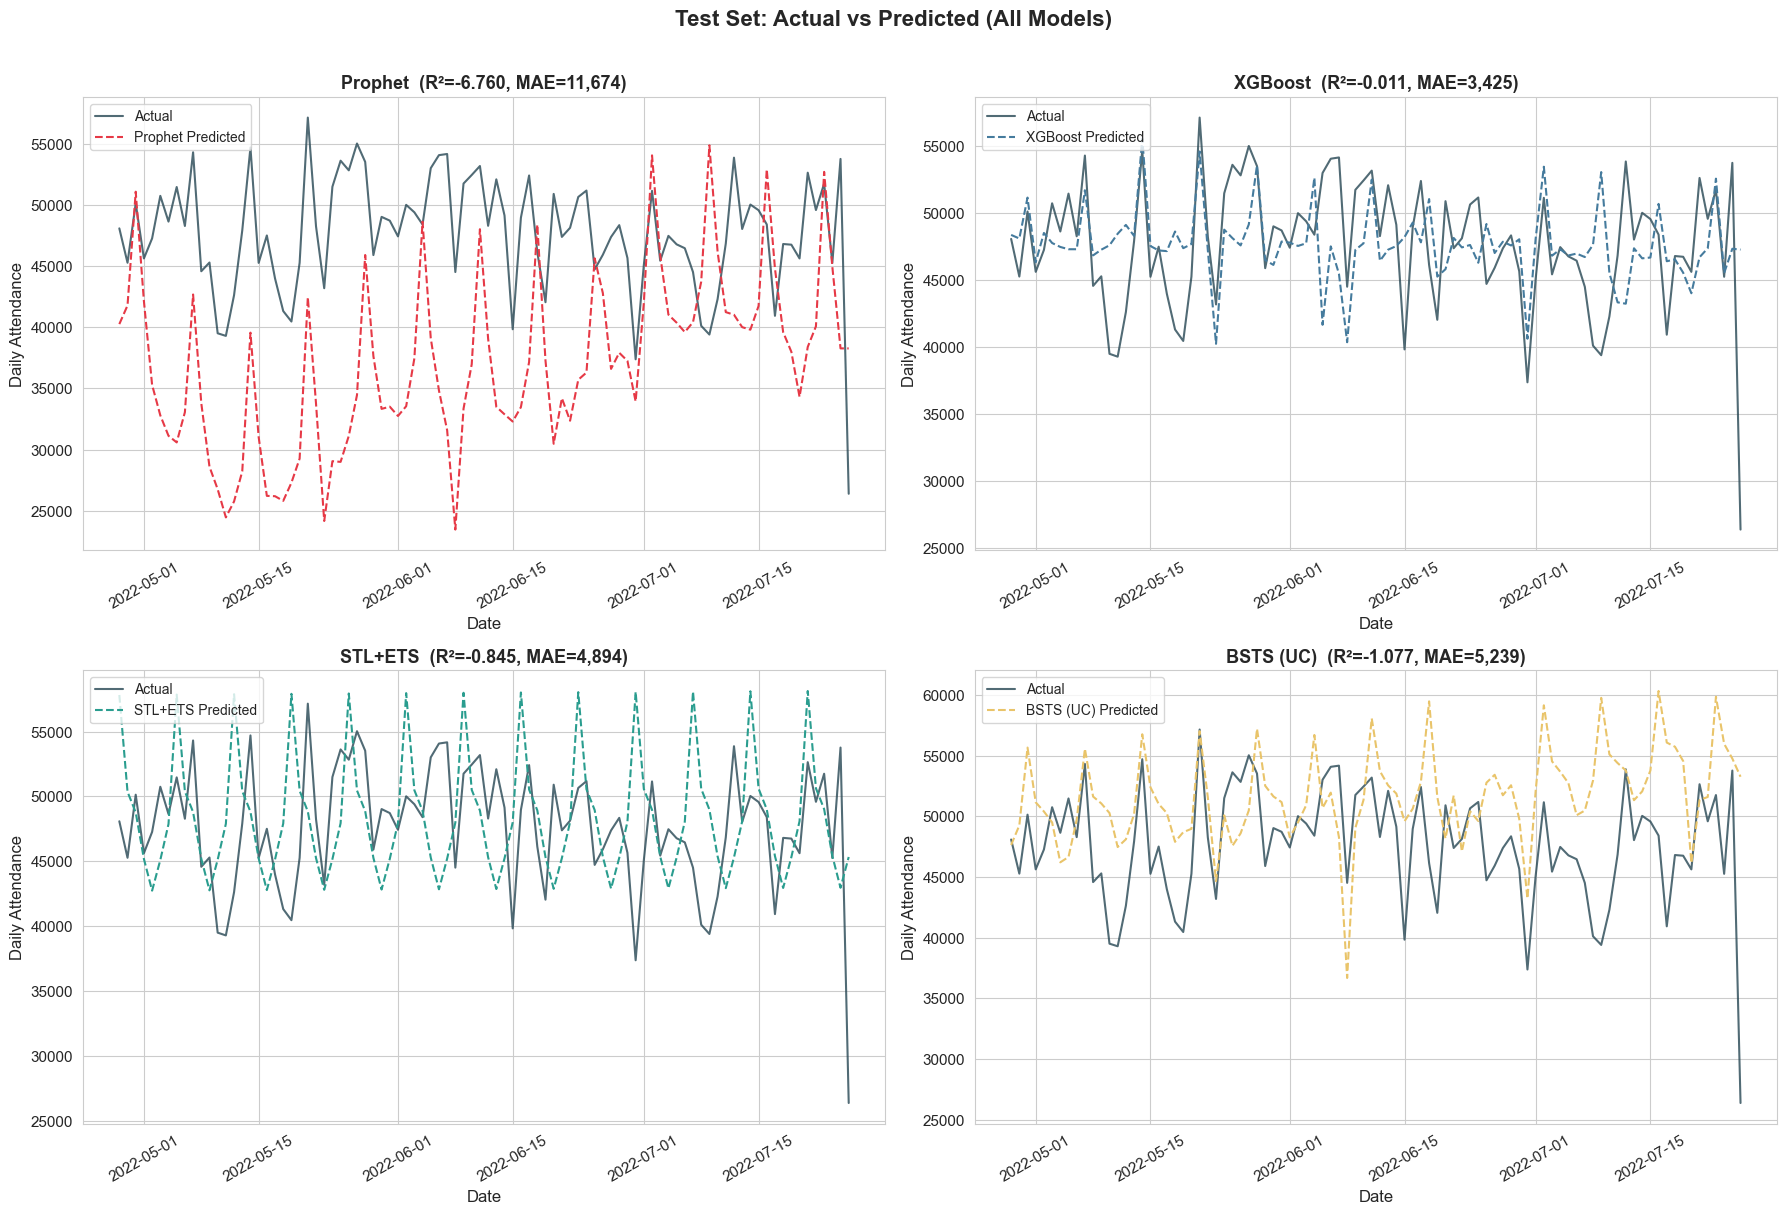

In [15]:
# ============================================================
# 7b. ACTUAL VS PREDICTED PLOT — All daily models on test set
# ============================================================
test_dates = test_df['date'].values
y_actual = test_df['y'].values

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Test Set: Actual vs Predicted (All Models)', fontsize=16, fontweight='bold', y=1.01)

colors = {'Prophet': '#E63946', 'XGBoost': '#457B9D', 'STL+ETS': '#2A9D8F', 'BSTS (UC)': '#E9C46A'}

for ax, (name, color) in zip(axes.flat, colors.items()):
    # Handle XGBoost's potentially different date alignment
    if name == 'XGBoost':
        xdates, xpred, xactual = predictions[name]
        ax.plot(xdates, xactual, color='#264653', linewidth=1.5, label='Actual', alpha=0.8)
        ax.plot(xdates, xpred, color=color, linewidth=1.5, label=f'{name} Predicted', linestyle='--')
        r2_val = results[name]['R2']
        mae_val = results[name]['MAE']
    else:
        pred = predictions[name]
        ax.plot(test_dates, y_actual, color='#264653', linewidth=1.5, label='Actual', alpha=0.8)
        ax.plot(test_dates, pred, color=color, linewidth=1.5, label=f'{name} Predicted', linestyle='--')
        r2_val = results[name]['R2']
        mae_val = results[name]['MAE']

    ax.set_title(f'{name}  (R²={r2_val:.3f}, MAE={mae_val:,.0f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Attendance')
    ax.legend(loc='upper left', fontsize=10)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('model_comparison_test_predictions.png', dpi=200, bbox_inches='tight')
plt.show()

### 7c. Residual Analysis

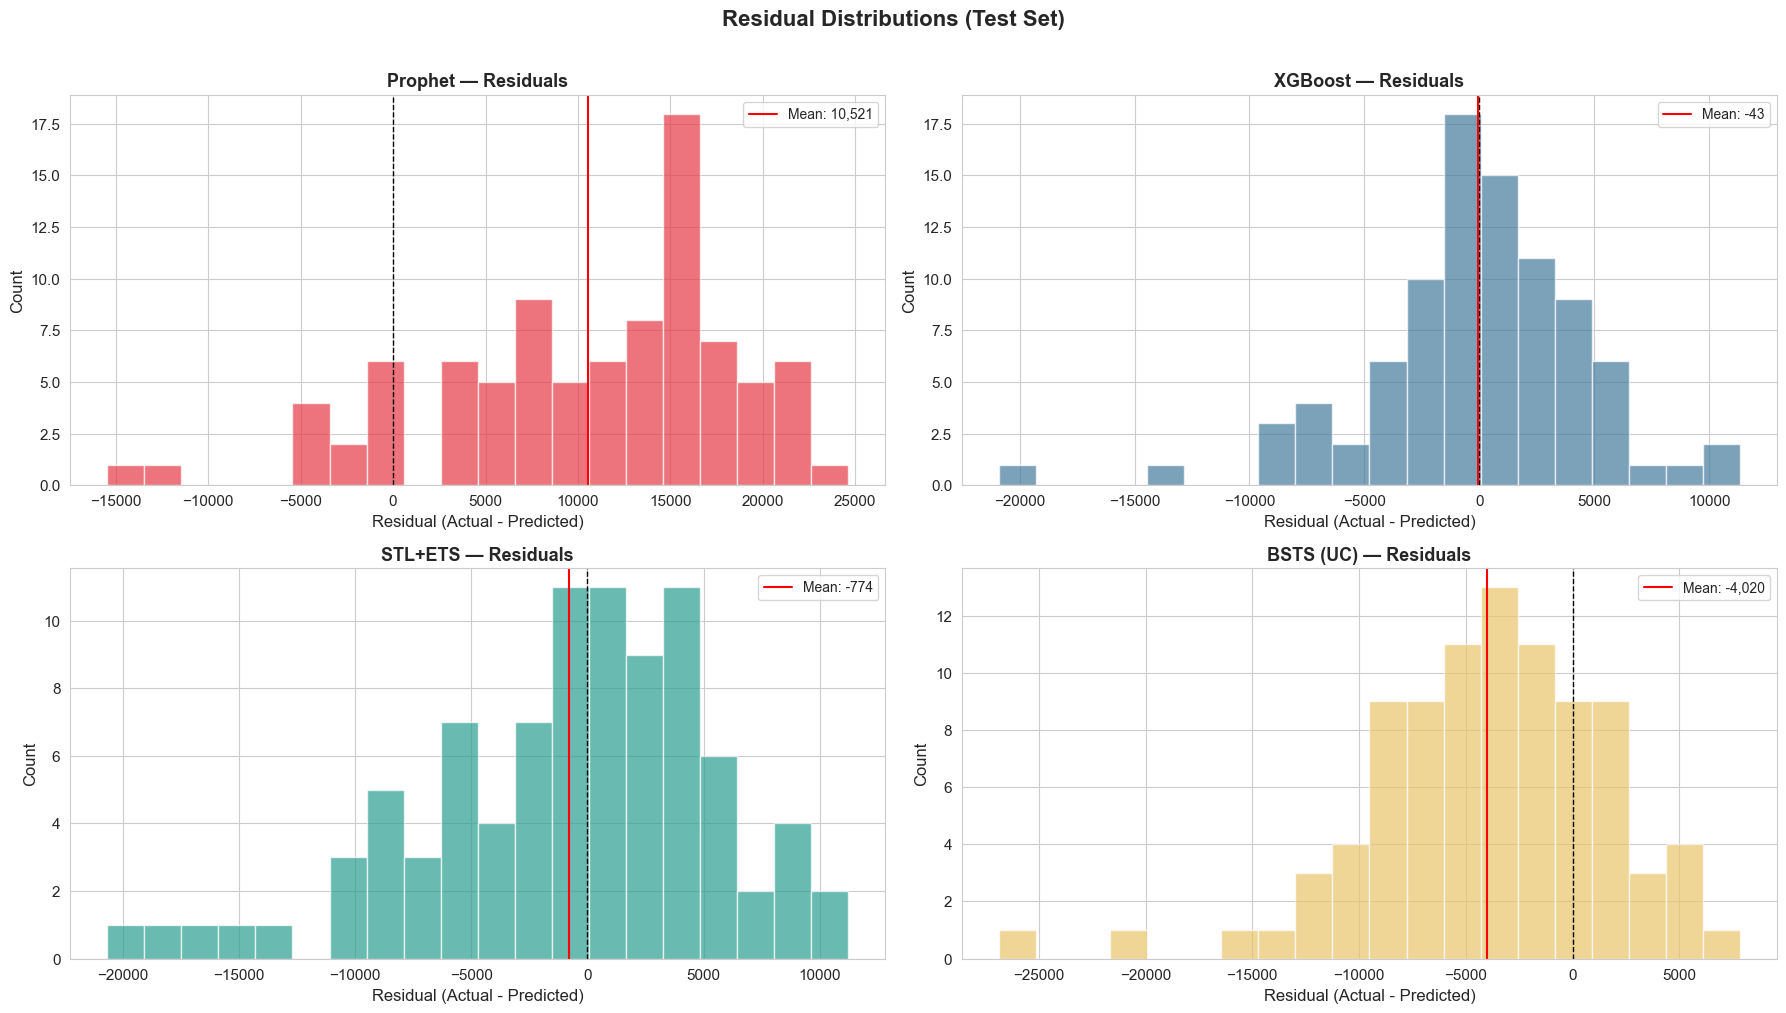

In [16]:
# ============================================================
# 7c. RESIDUAL ANALYSIS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Residual Distributions (Test Set)', fontsize=16, fontweight='bold', y=1.01)

for ax, (name, color) in zip(axes.flat, colors.items()):
    if name == 'XGBoost':
        _, xpred, xactual = predictions[name]
        residuals = xactual - xpred
    else:
        pred = predictions[name]
        residuals = y_actual - pred

    ax.hist(residuals, bins=20, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(np.mean(residuals), color='red', linestyle='-', linewidth=1.5,
               label=f'Mean: {np.mean(residuals):,.0f}')
    ax.set_title(f'{name} — Residuals', fontsize=13, fontweight='bold')
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_residuals.png', dpi=200, bbox_inches='tight')
plt.show()

### 7d. Bar Chart — Metrics Comparison

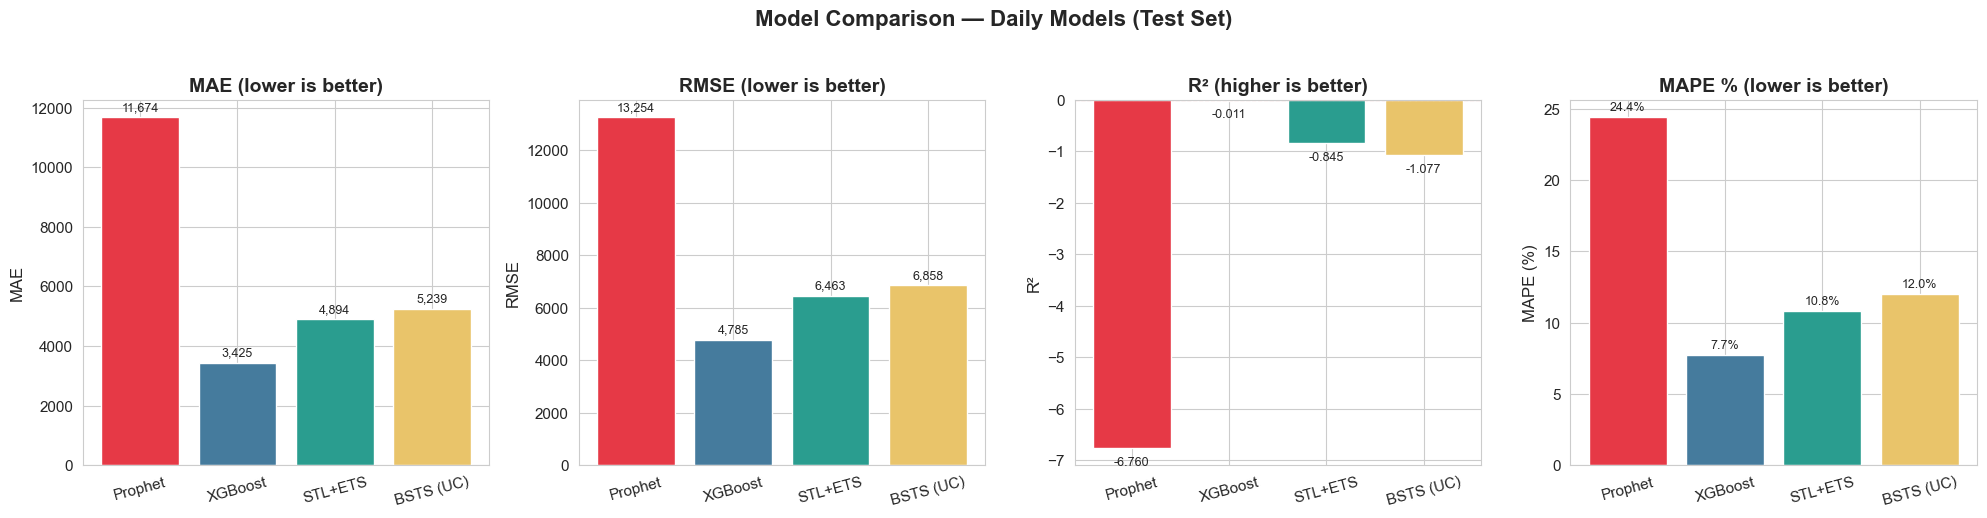

In [17]:
# ============================================================
# 7d. BAR CHART COMPARISON
# ============================================================
# Only daily models for fair comparison
daily_models = ['Prophet', 'XGBoost', 'STL+ETS', 'BSTS (UC)']
daily_results = {k: results[k] for k in daily_models if k in results}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Model Comparison — Daily Models (Test Set)', fontsize=16, fontweight='bold', y=1.03)

model_names = list(daily_results.keys())
bar_colors = [colors.get(m, '#999') for m in model_names]

# MAE
vals = [daily_results[m]['MAE'] for m in model_names]
axes[0].bar(model_names, vals, color=bar_colors, edgecolor='white')
axes[0].set_title('MAE (lower is better)', fontweight='bold')
axes[0].set_ylabel('MAE')
for i, v in enumerate(vals):
    axes[0].text(i, v + max(vals)*0.02, f'{v:,.0f}', ha='center', fontsize=9)

# RMSE
vals = [daily_results[m]['RMSE'] for m in model_names]
axes[1].bar(model_names, vals, color=bar_colors, edgecolor='white')
axes[1].set_title('RMSE (lower is better)', fontweight='bold')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(vals):
    axes[1].text(i, v + max(vals)*0.02, f'{v:,.0f}', ha='center', fontsize=9)

# R²
vals = [daily_results[m]['R2'] for m in model_names]
axes[2].bar(model_names, vals, color=bar_colors, edgecolor='white')
axes[2].set_title('R² (higher is better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
for i, v in enumerate(vals):
    offset = max(abs(min(vals)), max(vals)) * 0.05
    axes[2].text(i, v + offset if v >= 0 else v - offset, f'{v:.3f}', ha='center', fontsize=9)

# MAPE
vals = [daily_results[m]['MAPE'] for m in model_names]
axes[3].bar(model_names, vals, color=bar_colors, edgecolor='white')
axes[3].set_title('MAPE % (lower is better)', fontweight='bold')
axes[3].set_ylabel('MAPE (%)')
for i, v in enumerate(vals):
    axes[3].text(i, v + max(vals)*0.02, f'{v:.1f}%', ha='center', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=200, bbox_inches='tight')
plt.show()

### 7e. Full Timeline — All Models Overlaid

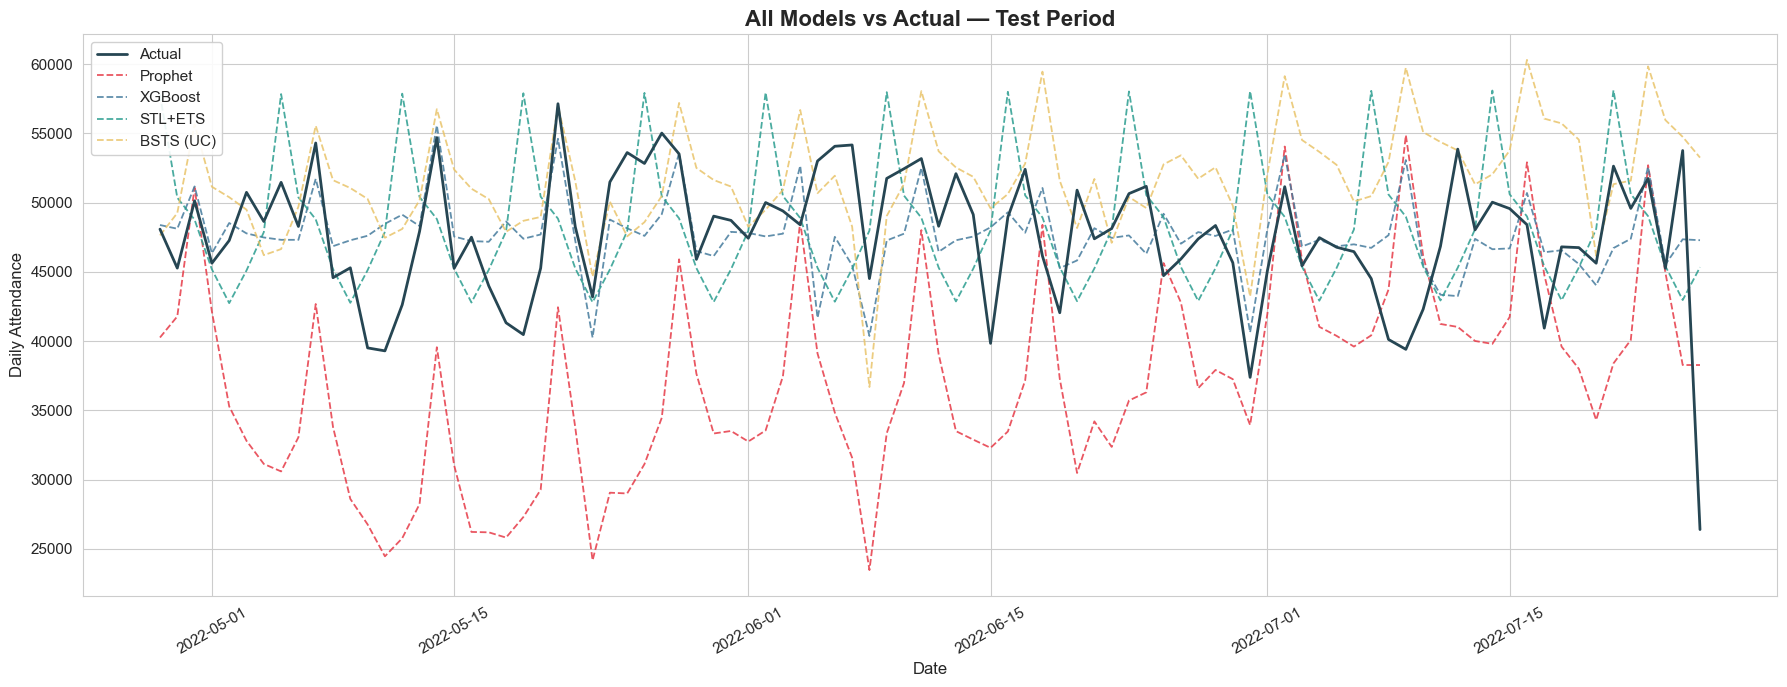

In [18]:
# ============================================================
# 7e. OVERLAY ALL MODELS ON TEST SET
# ============================================================
fig, ax = plt.subplots(figsize=(18, 7))

# Actual
ax.plot(test_dates, y_actual, color='#264653', linewidth=2, label='Actual', zorder=5)

# Each model
overlay_colors = {'Prophet': '#E63946', 'XGBoost': '#457B9D', 'STL+ETS': '#2A9D8F', 'BSTS (UC)': '#E9C46A'}
for name, color in overlay_colors.items():
    if name == 'XGBoost':
        xdates, xpred, _ = predictions[name]
        ax.plot(xdates, xpred, color=color, linewidth=1.3, label=name, linestyle='--', alpha=0.85)
    else:
        pred = predictions[name]
        ax.plot(test_dates, pred, color=color, linewidth=1.3, label=name, linestyle='--', alpha=0.85)

ax.set_title('All Models vs Actual — Test Period', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Attendance', fontsize=12)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('model_comparison_overlay.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Conclusions

### Results Summary

| Model | MAE | RMSE | MAPE | Note |
|-------|-----|------|------|------|
| **XGBoost** | **3,425** | **4,785** | **7.71%** | Best performer (daily, with lag + weather features) |
| **STL+ETS** | 4,894 | 6,463 | 10.80% | Solid pure time-series baseline (no exog) |
| **BSTS (UC)** | 5,239 | 6,858 | 12.00% | Best structural model with COVID intervention |
| **Prophet** | 11,674 | 13,254 | 24.42% | Seasonal decomposition interpretable but less accurate |
| **SARIMAX (auto, monthly)** | 117,338 | 124,554 | 8.52% | Improved over original, but monthly scale |
| **SARIMAX (original, monthly)** | 644,359 | 790,039 | 58.23% | Original baseline — severely overfit |

### Key Takeaways

1. **XGBoost is the clear winner** — MAPE of 7.71% vs the original 58.23%, a ~7.5x improvement. Lag features (especially `lag_7` and `roll_mean_7`) and weather (temperature) are the most important predictors.

2. **Daily data unlocks ~20x more training samples** — moving from ~50 monthly points to ~1,100 daily points is crucial for all models.

3. **COVID handling matters** — Excluding COVID from training (STL+ETS), using it as a holiday window (Prophet), or modeling it as a level intervention (BSTS) all outperform the simple binary dummy approach.

4. **Weather features add signal** — Temperature and rain are among the top features in XGBoost, confirming the value of the weather data available in `final_data/`.

5. **Prophet underperformed expectations** — likely because the COVID lockdown window creates artifacts in the changepoint detection. Could be improved with more careful tuning of `changepoint_prior_scale` and the holiday window definition.

### Recommended Production Model: XGBoost
- Requires lag features (needs historical data at inference time)
- Feature importance is interpretable
- Can be easily retrained as new data arrives
- Consider ensemble with BSTS for uncertainty quantification